In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization

In [2]:
RAVDESS_PATH = "D:/SER_Cross/RAVDESS"
CREMA_PATH = "D:/SER_Cross/CREMA"

emotions_map = {
    'angry': 'angry',
    'happy': 'happy',
    'sad': 'sad'
}

In [3]:
def get_emotion_ravdess(file):
    emotion_code = int(file.split('-')[2])
    if emotion_code == 5:
        return 'angry'
    elif emotion_code == 3:
        return 'happy'
    elif emotion_code == 4:
        return 'sad'
    return None


def get_emotion_crema(file):
    if "ANG" in file:
        return 'angry'
    elif "HAP" in file:
        return 'happy'
    elif "SAD" in file:
        return 'sad'
    return None

In [4]:
def extract_logmel(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    max_len = 3 * sr
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_mel = librosa.power_to_db(mel)

    return log_mel

In [5]:
X = []
y = []

# RAVDESS
for root, _, files in os.walk(RAVDESS_PATH):
    for file in files:
        if file.endswith(".wav"):
            emotion = get_emotion_ravdess(file)
            if emotion:
                path = os.path.join(root, file)
                feature = extract_logmel(path)
                X.append(feature)
                y.append(emotion)

# CREMA
for root, _, files in os.walk(CREMA_PATH):
    for file in files:
        if file.endswith(".wav"):
            emotion = get_emotion_crema(file)
            if emotion:
                path = os.path.join(root, file)
                feature = extract_logmel(path)
                X.append(feature)
                y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Data loaded:", X.shape, y.shape)

Data loaded: (0,) (0,)


In [6]:
# Normalize
X = (X - np.mean(X)) / np.std(X)

# Add channel dimension
X = X[..., np.newaxis]

print("Final shape:", X.shape)

Final shape: (0, 1)


c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("y sample:", y[:10])

X shape: (0, 1)
y shape: (0,)
y sample: []


In [10]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [11]:
print(df_train.head())

                                                path  emotion   speaker  \
0  D:\SER_Cross\data\processed\ravdess_audio\Acto...  neutral  actor_02   
1  D:\SER_Cross\data\processed\ravdess_audio\Acto...  neutral  actor_02   
2  D:\SER_Cross\data\processed\ravdess_audio\Acto...  neutral  actor_02   
3  D:\SER_Cross\data\processed\ravdess_audio\Acto...  neutral  actor_02   
4  D:\SER_Cross\data\processed\ravdess_audio\Acto...  neutral  actor_02   

   dataset  
0  ravdess  
1  ravdess  
2  ravdess  
3  ravdess  
4  ravdess  


In [12]:
df_train = df_train[df_train['emotion'].isin(['angry', 'happy', 'sad'])]
df_val   = df_val[df_val['emotion'].isin(['angry', 'happy', 'sad'])]
df_test  = df_test[df_test['emotion'].isin(['angry', 'happy', 'sad'])]

In [13]:
print(df_train['emotion'].value_counts())

emotion
happy    1028
sad      1028
angry    1028
Name: count, dtype: int64


In [14]:
def process_dataframe(df):
    X = []
    y = []

    for _, row in df.iterrows():
        file_path = row['path']
        label = row['emotion']

        try:
            feature = extract_logmel(file_path)
            X.append(feature)
            y.append(label)
        except:
            continue

    return np.array(X), np.array(y)

In [15]:
X_train, y_train = process_dataframe(df_train)
X_val, y_val     = process_dataframe(df_val)
X_test, y_test   = process_dataframe(df_test)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: (3084, 128, 130)
Val: (621, 128, 130)
Test: (684, 128, 130)


In [16]:
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_val   = (X_val - np.mean(X_val)) / np.std(X_val)
X_test  = (X_test - np.mean(X_test)) / np.std(X_test)

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

In [17]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)
y_test_cat  = to_categorical(y_test_enc)

In [18]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

In [19]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)
y_test_cat  = to_categorical(y_test_enc)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128, 130, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 128, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 126, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 62, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 61, 62, 64)        256       
 chNormalization)                                                
                                                        

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=32
)

Epoch 1/30
97/97 [==============================] - 28s 276ms/step - loss: 1.5337 - accuracy: 0.5503 - val_loss: 2.3285 - val_accuracy: 0.4348
Epoch 2/30
97/97 [==============================] - 29s 297ms/step - loss: 0.8867 - accuracy: 0.5473 - val_loss: 4.0007 - val_accuracy: 0.4026
Epoch 3/30
97/97 [==============================] - 29s 297ms/step - loss: 0.8439 - accuracy: 0.5756 - val_loss: 2.2419 - val_accuracy: 0.3961
Epoch 4/30
97/97 [==============================] - 29s 300ms/step - loss: 0.7861 - accuracy: 0.6219 - val_loss: 1.0967 - val_accuracy: 0.5330
Epoch 5/30
97/97 [==============================] - 29s 295ms/step - loss: 0.7557 - accuracy: 0.6274 - val_loss: 1.0620 - val_accuracy: 0.6345
Epoch 6/30
97/97 [==============================] - 29s 297ms/step - loss: 0.7465 - accuracy: 0.6323 - val_loss: 0.8215 - val_accuracy: 0.6602
Epoch 7/30
97/97 [==============================] - 30s 309ms/step - loss: 0.7599 - accuracy: 0.6252 - val_loss: 0.8606 - val_accuracy: 0.6651

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("CNN Log-Mel Test Accuracy:", test_acc)

22/22 [==============================] - 2s 75ms/step - loss: 0.5026 - accuracy: 0.7909
CNN Log-Mel Test Accuracy: 0.7909356951713562


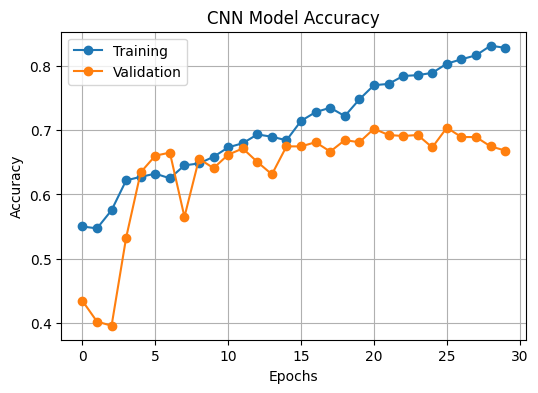

In [24]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])
plt.grid()

plt.savefig('cnn_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

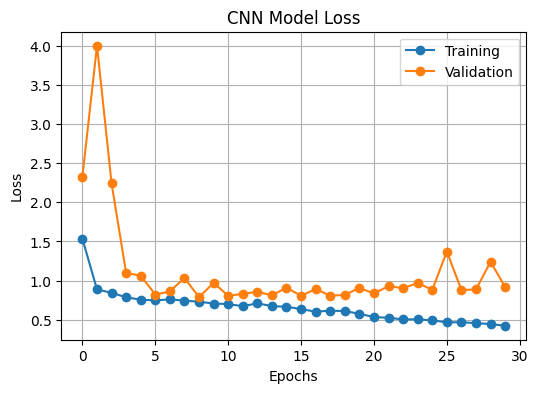

In [25]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])
plt.grid()

plt.savefig('cnn_loss.png', dpi=300, bbox_inches='tight')
plt.show()

22/22 [==============================] - 1s 59ms/step


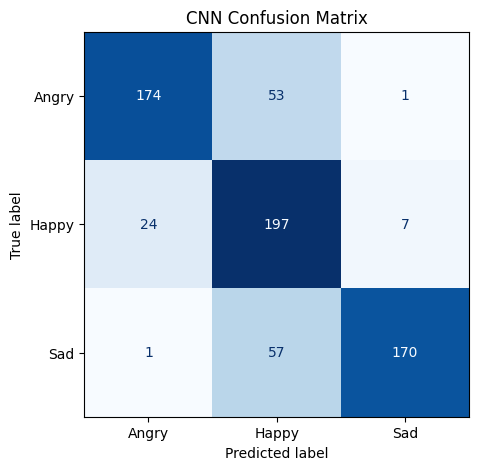

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

labels = ['Angry', 'Happy', 'Sad']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('CNN Confusion Matrix')
plt.savefig('cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred_classes, target_names=['Angry', 'Happy', 'Sad'])

print(report)

              precision    recall  f1-score   support

       Angry       0.87      0.76      0.81       228
       Happy       0.64      0.86      0.74       228
         Sad       0.96      0.75      0.84       228

    accuracy                           0.79       684
   macro avg       0.82      0.79      0.80       684
weighted avg       0.82      0.79      0.80       684

